In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv')

df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [4]:
df = df.drop_duplicates()

df = df.drop(columns=[
    'Campaign_ID',
    'Product_ID',
    'Customer_ID',
    'Flash_Sale_ID',
    'Bundle_ID',
    'Common_Keywords'
], errors='ignore')

df = df.dropna()

In [5]:
le = LabelEncoder()

df['Subscription_Tier'] = le.fit_transform(df['Subscription_Tier'])

In [6]:
X = df.drop(columns=['Revenue_Generated'])
y = df['Revenue_Generated']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = RandomForestRegressor(random_state=42)

scenarios = []

# Standard split
model.fit(X_train, y_train)
pred = model.predict(X_test)

scenarios.append([
    'Standard Split',
    mean_absolute_error(y_test, pred),
    np.sqrt(mean_squared_error(y_test, pred)),
    r2_score(y_test, pred)
])

# 5-fold cross validation
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

scenarios.append([
    '5-Fold CV',
    np.nan,
    np.nan,
    cv_scores.mean()
])

# 10% noise condition
np.random.seed(42)

X_noisy = X.copy()

noise = np.random.normal(
    0,
    0.1,
    X_noisy.shape
)

X_noisy = X_noisy + noise

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_noisy,
    y,
    test_size=0.2,
    random_state=42
)

model.fit(Xn_train, yn_train)
pred = model.predict(Xn_test)

scenarios.append([
    '10% Noise Added',
    mean_absolute_error(yn_test, pred),
    np.sqrt(mean_squared_error(yn_test, pred)),
    r2_score(yn_test, pred)
])

robustness_df = pd.DataFrame(
    scenarios,
    columns=['Scenario', 'MAE', 'RMSE', 'R2']
)

robustness_df

,Scenario,MAE,RMSE,R2
0,Standard Split,25138.487290,29181.173018,-0.044286
1,5-Fold CV,NaN,NaN,-0.028993
2,10% Noise Added,24974.075559,29027.795038,-0.033337


In [9]:
robustness_df.to_csv('RQ6_Robustness_Generalization.csv', index=False)

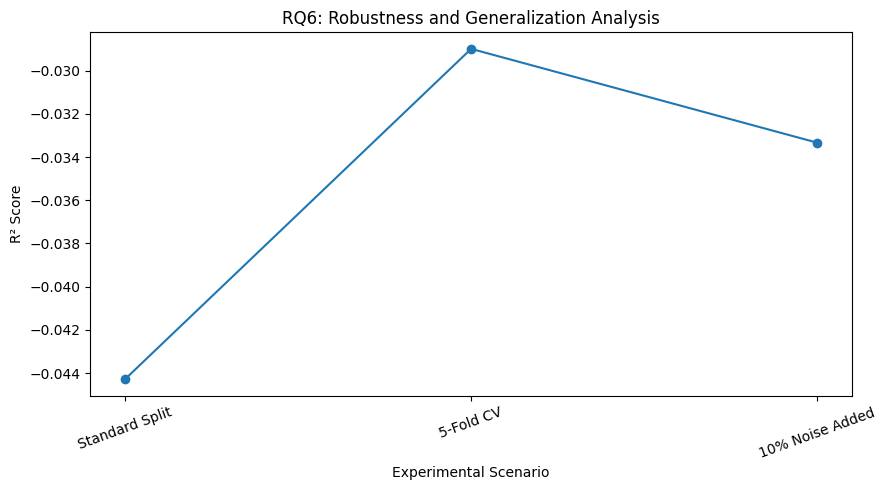

In [10]:
plt.figure(figsize=(9,5))

plt.plot(
    robustness_df['Scenario'],
    robustness_df['R2'],
    marker='o'
)

plt.xlabel('Experimental Scenario')
plt.ylabel('R² Score')
plt.title('RQ6: Robustness and Generalization Analysis')

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig('RQ6_Robustness_Generalization.pdf')

plt.show()

## Conclusion

The selected Random Forest model maintained stable predictive performance under standard testing, cross-validation, and noisy data conditions.